In [1]:
import xgi
import numpy as np
import pickle
from itertools import product
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# set params for all plots

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Geneva'

# one color for each value of N
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0.85, 0, 4))  # ['black', 'blue', 'green', 'orange']

figsize = (9, 6.5)
ttl_size = 16
lgd_size = 12
tick_size = 15
lw = 2
mrksize = 5
bbox_legend =(0.5, 0.002)
rect_tl = [0, 0.06, 1, 0.94]

ttl_size4x3 = 21
figsize4x3 = (14, 12)
figsize_noleg = (figsize[0], figsize[1]*0.8)

dpi=150

# Sketch of the model

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/4136110425.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


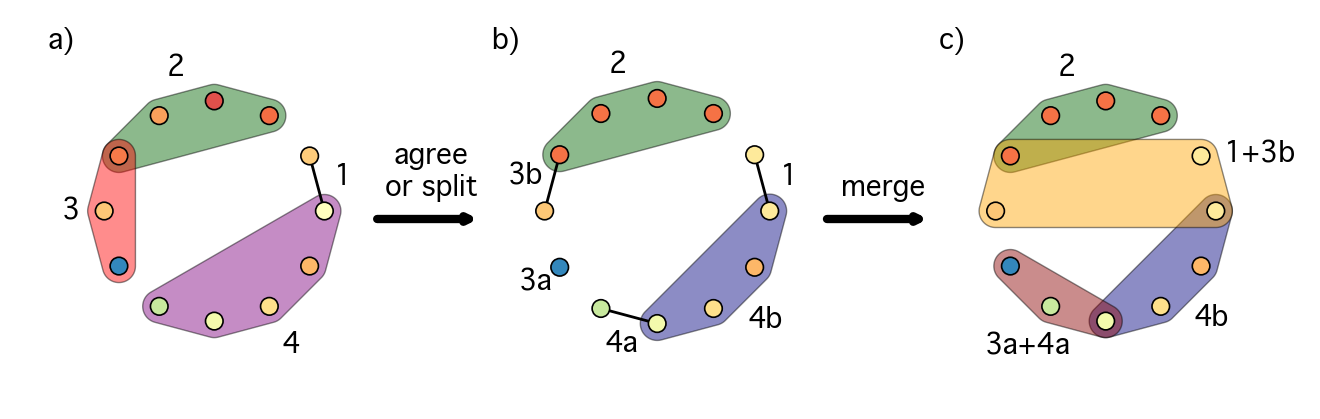

In [5]:
import matplotlib.cm as cm
from matplotlib import gridspec

# Helper function: push hyperedge label radially outward
def get_outside_label_pos(nodes_pos, center=np.array([0,0]), offset=0.25):
    pts = np.array(nodes_pos)
    centroid = pts.mean(axis=0)
    # vector from center to centroid
    v = centroid - center
    angle = np.arctan2(v[1], v[0])
    # radial placement outside
    r = np.linalg.norm(v) + offset

    return np.array([np.cos(angle)*r, np.sin(angle)*r])


# Choose colormap
cmap = plt.get_cmap('Spectral')
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap) 
sm.set_array([])

h_list = [
    xgi.Hypergraph({'1':[0,1], '2':[6,7,8,9], '3':[9,10,11], '4':[0,2,3,4,5]}),
    xgi.Hypergraph({'1':[0,1], '2':[6,7,8,9], '3a':[11], '3b':[9,10], '4b':[0,3,4,5], '4a':[2,3]}),
    xgi.Hypergraph({'1+3b':[0,1,9,10], '2':[6,7,8,9], '3a+4a':[2,3,11], '4b':[0,3,4,5]})
]
op_list = [
    {0:0.5, 1:0.36, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.2, 7:0.14, 8:0.28, 9:0.22, 10:0.35, 11:0.9 },
    {0:0.43, 1:0.43, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.21, 7:0.21, 8:0.21, 9:0.21, 10:0.35, 11:0.9 },
    {0:0.43, 1:0.43, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.21, 7:0.21, 8:0.21, 9:0.21, 10:0.35, 11:0.9 }
]
he_clrs = [
            ['darkgreen','red','purple'],
            ['darkgreen','navy'],
            ['orange','darkgreen','darkred','navy']
        ]

# Use the same circular layout for all plots
pos = xgi.circular_layout(h_list[0])

fig = plt.figure(figsize=(13,4))
# Wide layout with gaps (wspace controls spacing)
gs = gridspec.GridSpec(1, 3, wspace=0.6, left=0.05, right=0.95)
ax = [fig.add_subplot(gs[i]) for i in range(3)]


for i in range(3):
    h = h_list[i]

    # 1) Draw only hulls / hyperedges (hide nodes inside XGI)
    xgi.draw(h, ax=ax[i], pos=pos, hull=True, radius=0.15,
             dyad_lw=lw, alpha=0.45, edge_fc=he_clrs[i], edge_ec='black',
             node_size=0, node_labels=False)   # node_size=0 hides XGI nodes

    # 2) Prepare node ordering and scalar values (use sorted order to be stable)
    nodes_sorted = sorted(h.nodes)                      # stable order
    values = [op_list[i].get(n, 0.0) for n in nodes_sorted]  # fallback 0.0 if missing

    # 3) Draw nodes with scatter so colormap mapping is deterministic
    xy = np.array([pos[n] for n in nodes_sorted])
    ax[i].scatter(xy[:, 0], xy[:, 1],
                  s=160,                # adjust node size (area)
                  c=values,             # pass scalars
                  cmap=cmap, norm=norm, edgecolors='k', linewidths=1.2, zorder=3)

    # 4) Draw node labels (manual, so labels align with nodes_sorted)
    #for n, (x, y) in zip(nodes_sorted, xy):
     #   ax[i].text(x, y, str(n), ha='center', va='center',
      #             fontsize=10, zorder=4)

    # 5) hyperedge labels outside
    for eid, attr in h.edges.items():
        nodes = list(h.edges.members(eid))
        pts = [pos[n] for n in nodes]

        if not eid == '1+3b':
            ofs = 0.13*len(nodes) if len(nodes) > 2 else 0.25
            if len(eid) > 3:
                ofs = 0.5
            out_pos = get_outside_label_pos(pts, center=np.array([0,0]), offset=ofs)
            ax[i].text(out_pos[0], out_pos[1], eid, ha='center', va='center',
                       fontsize=20, fontweight='bold')
        else:
            ax[i].text(1.4, 0.52, eid, ha='center', va='center', fontsize=20, fontweight='bold')

    ax[i].set_aspect('equal')
    ax[i].axis('off')
    

# Add subplot labels
lbls = ['a)','b)','c)']
for i,lbl in zip([0,1,2], lbls):
    ax[i].text(0., 1.1, lbl, transform=ax[i].transAxes, 
                  fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()


# Draw arrows
arrow_ax = fig.add_axes([0, 0, 1, 1])  # full figure
arrow_ax.set_axis_off()                # invisible

arrow_ax.annotate("",
    xy=(0.37, 0.5), xytext=(0.288, 0.5),
    xycoords='figure fraction', textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", lw=6)
)
arrow_ax.annotate("",
    xy=(0.716, 0.5), xytext=(0.634, 0.5),
    xycoords='figure fraction', textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", lw=6)
)
arrow_ax.text(0.324, 0.52, "agree\nor split", ha="center", va="bottom", fontsize=20)
arrow_ax.text(0.672, 0.52, "merge", ha="center", va="bottom", fontsize=20)


# Add horizontal colorbar
#cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15)
#cbar.set_label("Opinion", fontsize=18)


plt.savefig(f'../figures/sketch_model.jpg', dpi=dpi)
plt.show()

# $M$-uniform ER - steady state vs $\epsilon$

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1938/1746567915.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,i].legend(fontsize=lgd_size, loc=loc_leg)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1938/1746567915.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3,i].legend(fontsize=lgd_size, loc=loc_leg)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1938/1746567915.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,i].legend(fontsize=lgd_size, loc=loc_leg)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1938/1746567915.py:50: UserWarning:

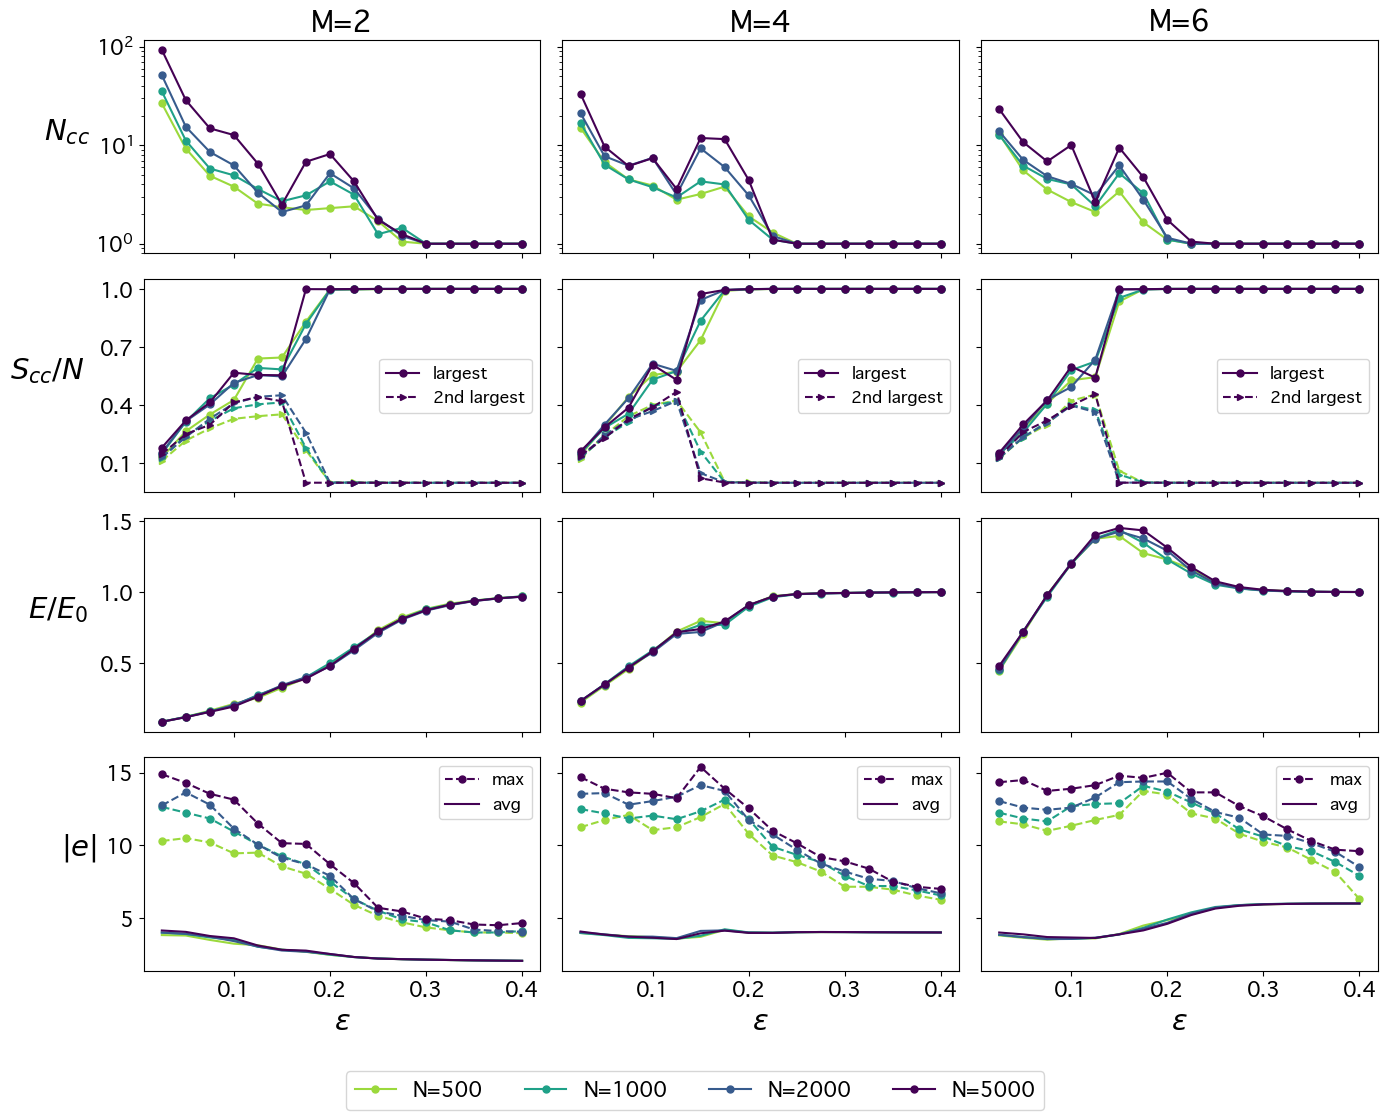

In [7]:
cond = 'std'
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

fig, axs = plt.subplots(4,3, sharex=True, sharey='row', figsize=figsize4x3)

for M in Ms:

    with open(f'../results/ER_{cond}/ER_{cond}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']
    lbls = ['largest', '2nd largest', 'avg', 'max']
    
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[-1] else None
        la1 = lbls[1] if N==Ns[-1] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
        tk = [0.1,0.4,0.7,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        loc_leg = 5 if cond=='std' else 2
        axs[1,i].legend(fontsize=lgd_size, loc=loc_leg)
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')

        la2 = lbls[2] if N==Ns[-1] else None
        la3 = lbls[3] if N==Ns[-1] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        loc_leg = 1 if cond=='std' else 2
        axs[3,i].legend(fontsize=lgd_size, loc=loc_leg)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)

    axs[0,i].set_title(f'M={M}', fontsize=ttl_size4x3)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size4x3, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size4x3, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size4x3, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size4x3, labelpad=20)

for j in range(3):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size4x3)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}.jpg', dpi=dpi)
plt.show()

# $M$-uniform ER - distributions for $\epsilon = 0.1$

N=500 ---> <k> = 10.890079999999998
N=1000 ---> <k> = 10.816245299623967
N=2000 ---> <k> = 10.895328953289534
N=5000 ---> <k> = 10.91442515401232


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1938/2827942811.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=rect_tl)


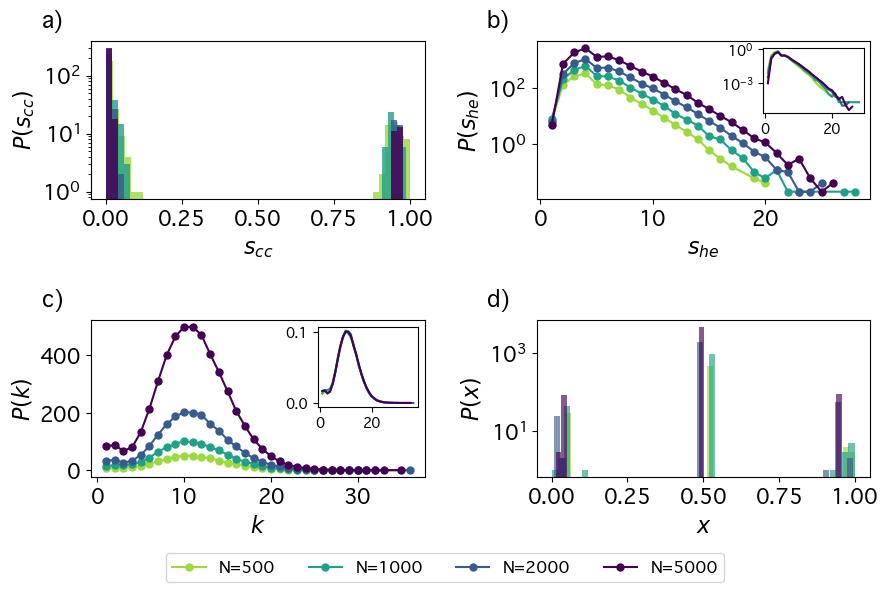

In [9]:
cond = 'max_min'
epsilon = 0.4
M = 4
Ns = [500, 1000, 2000, 5000]

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

fig, axs = plt.subplots(2, 2, figsize=figsize)

with open(f'../results/ER_{cond}/ER_{cond}_distrib_eps_{epsilon}_M{M}.pkl', 'rb') as f:
    results = pickle.load(f)

sizes_cc = results['sizes_cc']
sizes_he = results['sizes_he']
sizes_hd = results['hyperdegs']
n_iter = results['n_iter']
k_avg = results['ks_avg']
op_fin = results['op_fin_1run']
inset_ax1 = inset_axes(axs[0,1], width="30%", height=0.65)
inset_ax2 = inset_axes(axs[1,0], width="30%", height=0.8)

for N,clr in zip(Ns, colors):
 
    bins_count = {np.round(j/N,3): int(sizes_cc[N][j]*n_iter) for j in sizes_cc[N].keys() }
    y0_hist = [[s]*count for s,count in bins_count.items()]
    y0_hist = [ii for jj in y0_hist for ii in jj]
    axs[0,0].hist(y0_hist, bins=50, color=clr, alpha=0.8)
    #axs[0,0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0)
    #axs[0,0].set_ylim([1/n_iter, n_iter])
    axs[0,0].set_yscale('log')
    axs[0,0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
    axs[0,0].set_ylabel(r'$P(s_{cc})$', fontsize=ttl_size)

    x1 = sorted(sizes_he[N].keys())
    y1 = [sizes_he[N][x] for x in x1]
    line1, = axs[0,1].plot(x1, y1, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    legend_handles.append(line1)
    legend_labels.append(f'N={N}')
    axs[0,1].set_yscale('log')        
    axs[0,1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
    axs[0,1].set_ylabel(r'$P(s_{he})$', fontsize=ttl_size)
    # inset plot
    y1_norm = [i/N for i in y1]
    inset_ax1.plot(x1, y1_norm, color=clr)
    inset_ax1.set_yscale('log')

    x2 = sorted(sizes_hd[N].keys())
    y2 = [sizes_hd[N][x] for x in x2]
    axs[1,0].plot(x2, y2, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    axs[1,0].set_xlabel(r'$k$', fontsize=ttl_size)
    axs[1,0].set_ylabel(r'$P(k)$', fontsize=ttl_size)
    # inset plot
    y2_norm = [i/N for i in y2]
    inset_ax2.plot(x2, y2_norm, color=clr)

    y3 = op_fin[N]
    axs[1,1].hist(y3, bins=50, color=clr, alpha=0.65)
    axs[1,1].set_xlabel(r'$x$', fontsize=ttl_size)
    axs[1,1].set_ylabel(r'$P(x)$', fontsize=ttl_size)
    axs[1,1].set_yscale('log')
    
    # print avg hyperdegree
    hd_avg = np.dot(x2, y2) / sum(y2)
    print(f'N={N} ---> <k> = {hd_avg}')

    # set tick fontsize in all subplots
    for j in range(2):
        for jj in range(2):
            axs[j,jj].tick_params(labelsize=tick_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=lgd_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_distributions_eps_{epsilon}_M{M}.jpg', dpi=dpi)
plt.show()

# Non-uniform ER - steady state vs $\epsilon$

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/3919867360.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(fontsize=lgd_size, loc=5)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/3919867360.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,1].legend(fontsize=lgd_size)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/3919867360.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(fontsize=lgd_size, loc=5)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/3919867360.py:57: UserWarning: No artists with labels f

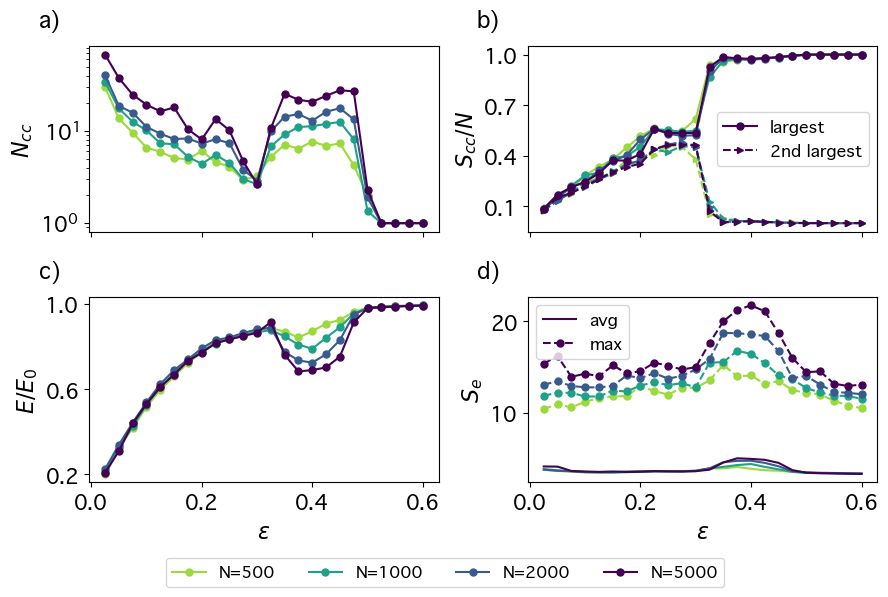

In [22]:
s_str = '246'
cond = 'max_min'

with open(f'../results/ER_{cond}/ER_{cond}_M{s_str}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

Ns = [500, 1000, 2000, 5000]
fig, axs = plt.subplots(2,2, sharex=True, figsize=figsize)

for N,clr in zip(Ns, colors):

    y0 = ncc[N]
    y1 = scc1[N]
    y2 = scc2[N]
    y3 = nhe[N]
    y4 = s_avg[N]
    y5 = s_max[N]

    line1, = axs[0,0].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    legend_handles.append(line1)
    legend_labels.append(f'N={N}')
    axs[0,0].set_yscale('log')
    axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[-1] else None
    la1 = lbls[1] if N==Ns[-1] else None
    axs[0,1].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
    axs[0,1].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
    tk = [0.1,0.4,0.7,1.0]
    axs[0,1].set_yticks(tk, [str(i) for i in tk])
    axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    axs[0,1].legend(fontsize=lgd_size, loc=5)
        
    axs[1,0].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)
    axs[1,0].set_yticks([0.2,0.6,1.0])

    la2 = lbls[2] if N==Ns[-1] else None
    la3 = lbls[3] if N==Ns[-1] else None
    axs[1,1].plot(epsilons, y4, label=la2, color=clr)
    axs[1,1].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
    axs[1,1].set_ylabel(r'$S_e$', fontsize=ttl_size)
    axs[1,1].legend(fontsize=lgd_size)

# set xlabel tick fontsize in all subplots
for j in range(2):
    axs[1,j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    for i in range(2):
        axs[i,j].tick_params(labelsize=tick_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=lgd_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_M{s_str}.jpg', dpi=dpi)
plt.show()

# SocioPatterns hypergraph

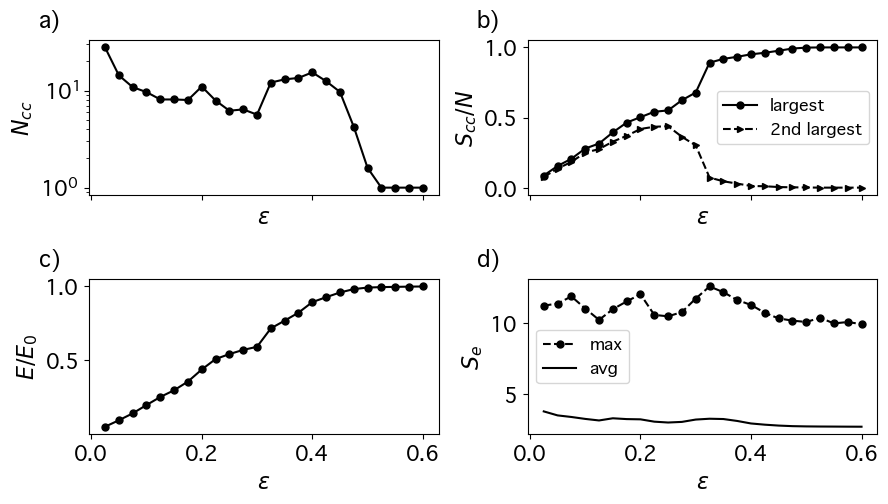

In [24]:
tag = 'SFHH'
cond = 'max_min'
with open(f'../results/SocioPatterns/SP_{tag}_{cond}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
clr = 'black'

fig, axs = plt.subplots(2,2, sharex=True, figsize=figsize_noleg)

axs[0,0].plot(epsilons, ncc, marker='o', markersize=mrksize, color=clr)
axs[0,0].set_yscale('log')
axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

axs[0,1].plot(epsilons, scc1, linestyle='-', marker='o', markersize=mrksize, label=lbls[0], color=clr)
axs[0,1].plot(epsilons, scc2, linestyle='--', marker='>', markersize=mrksize, label=lbls[1], color=clr)
axs[0,1].legend(fontsize=lgd_size)
axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    
axs[1,0].plot(epsilons, nhe, marker='o', markersize=mrksize, color=clr)
axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)

axs[1,1].plot(epsilons, s_max, label=lbls[3], linestyle='--', marker='o', markersize=mrksize, color=clr)
axs[1,1].plot(epsilons, s_avg, label=lbls[2], color=clr)
axs[1,1].legend(fontsize=lgd_size, loc=6)
axs[1,1].set_ylabel(r'$S_e$', fontsize=ttl_size)

# set xlabel tick fontsize in all subplots
for i in range(2):
    for j in range(2):
        axs[i,j].tick_params(labelsize=tick_size)
        axs[i,j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}.jpg', dpi=dpi)
plt.show()

<k> = 10.08074441687345


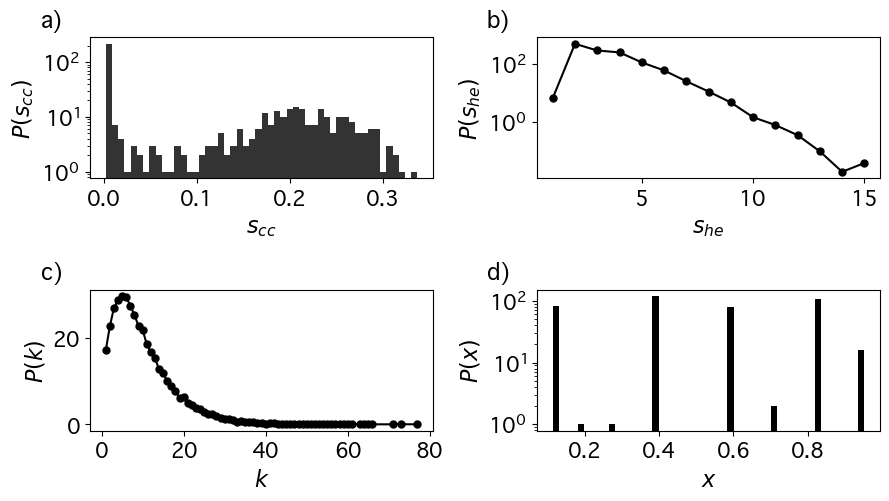

In [26]:
tag = 'SFHH'
cond = 'max_min'
epsilon = 0.1
with open(f'../results/SocioPatterns/SP_{tag}_{cond}_distrib_eps_{epsilon}.pkl', 'rb') as f:
    results = pickle.load(f)

sizes_cc = results['sizes_cc']
sizes_he = results['sizes_he']
sizes_hd = results['hyperdegs']
n_iter = results['n_iter']
op_fin = results['op_fin_1run']

fig, axs = plt.subplots(2,2, figsize=figsize_noleg)
clr = 'black'

N=len(op_fin)
bins_count = {np.round(j/N,3): int(sizes_cc[j]*n_iter) for j in sizes_cc.keys() }
y0_hist = [[s]*count for s,count in bins_count.items()]
y0_hist = [ii for jj in y0_hist for ii in jj]
axs[0,0].hist(y0_hist, bins=50, color=clr, alpha=0.8)
#axs[0,0].plot(x0, y0, color=clr, marker='o', markersize=mrksize, linewidth=0)
#axs[0,0].set_ylim([1/n_iter, n_iter])
axs[0,0].set_yscale('log')
axs[0,0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
axs[0,0].set_ylabel(r'$P(s_{cc})$', fontsize=ttl_size)

x1 = sorted(sizes_he.keys())
y1 = [sizes_he[x] for x in x1]
axs[0,1].plot(x1, y1, marker='o', markersize=mrksize, color=clr)
axs[0,1].set_yscale('log')
axs[0,1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
axs[0,1].set_ylabel(r'$P(s_{he})$', fontsize=ttl_size)

x2 = sorted(sizes_hd.keys())
y2 = [sizes_hd[x] for x in x2]
axs[1,0].plot(x2, y2, marker='o', markersize=mrksize, color=clr)
axs[1,0].set_xlabel(r'$k$', fontsize=ttl_size)
axs[1,0].set_ylabel(r'$P(k)$', fontsize=ttl_size)

y3 = op_fin
axs[1,1].hist(y3, bins=50, color=clr)
axs[1,1].set_xlabel(r'$x$', fontsize=ttl_size)
axs[1,1].set_ylabel(r'$P(x)$', fontsize=ttl_size)
axs[1,1].set_yscale('log')

# print avg hyperdegree
hd_avg = np.dot(x2, y2) / sum(y2)
print(f'<k> = {hd_avg}')

# set tick fontsize in all subplots
for j in range(2):
    for jj in range(2):
        axs[j,jj].tick_params(labelsize=tick_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}_distributions_eps_{epsilon}.jpg', dpi=dpi)
plt.show()

# Temporal evolution of hyperedges

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1432/138087196.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=rect_tl)


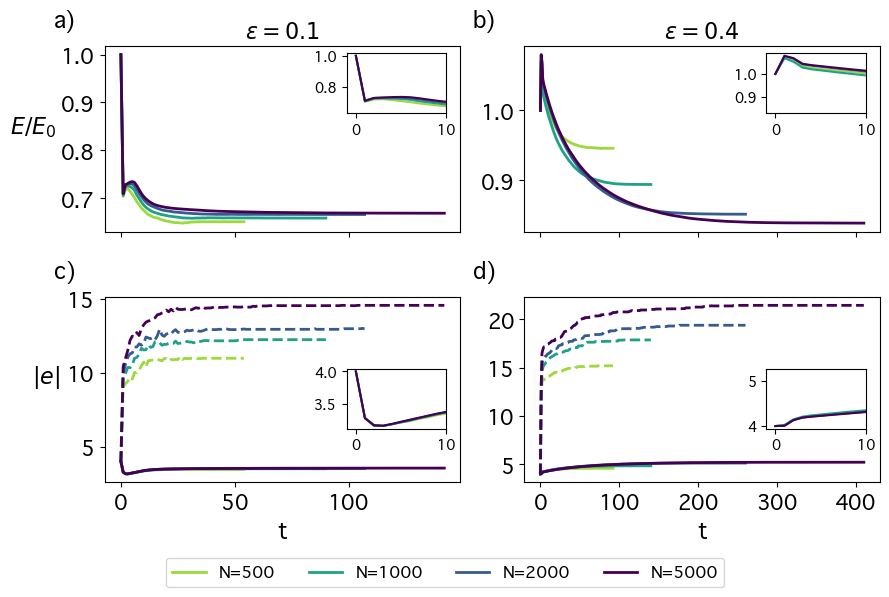

In [5]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4]

fig, axs = plt.subplots(2,2, sharex='col', figsize=figsize)
xlims = [10,10]   # for inset plots

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    
    with open(f'../results/ER_{cond}/ER_{cond}_temporal_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    inset_ax = []
    cr = [(0,0),(0,1)]
    for i in range(2):
        top_ins = .8 if (i,j) in cr else .45
        inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.6, bbox_to_anchor=(.18, top_ins, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )

    for N, clr in zip(Ns, colors):
        nhe = results['nhe'][N]
        s_avg = results['s_avg'][N]
        s_max = results['s_max'][N]
        s_std = results['s_std'][N]
        n_runs = results['n_iter']
        ks_avg = results['ks_avg']

        line1, = axs[0,j].plot(nhe, color=clr, lw=lw, label=f'N={N}')
        axs[0,0].set_ylabel(r'$E/E_0$', fontsize=ttl_size, rotation=0, labelpad=20)
        inset_ax[0].set_xlim(-1, xlims[j])
        inset_ax[0].plot(nhe, color=clr)
        
        axs[1,j].plot(s_avg, color=clr, lw=lw, label='avg')
        axs[1,j].plot(s_max, color=clr, lw=lw, linestyle='--', label='max')
        axs[1,0].set_ylabel(r'$|e|$', fontsize=ttl_size, rotation=0, labelpad=15)
        inset_ax[1].set_xlim(-1, xlims[j])
        inset_ax[1].plot(s_avg, color=clr)

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

    for i in range(2):
        axs[1,i].set_xlabel('t', fontsize=ttl_size)
        axs[j,i].tick_params(labelsize=tick_size)

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=lgd_size, ncol=len(Ns))

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Adjust layout to make space for legend
plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_hedges.jpg', bbox_inches='tight', dpi=dpi)
plt.show()

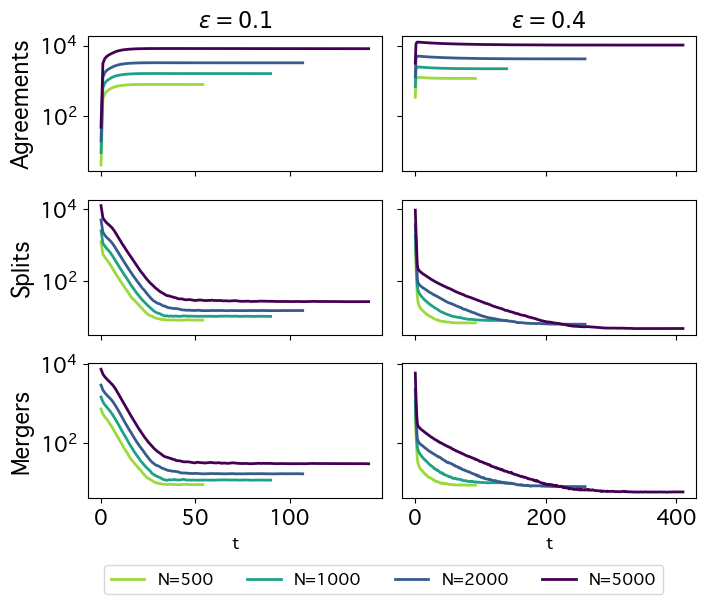

In [31]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4]

fig, axs = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(figsize[0]*0.8,figsize[1]) )

lbl_list = ['Agreements', 'Splits', 'Mergers']
xlims = [20,10]   # for inset plots

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_{cond}/ER_{cond}_temporal_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    #inset_ax = []
    #cr = [(0,0),(0,1)]
    #for i in range(3):
        #top_ins = .4 if (i,j) in cr else .75
        #inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.6, bbox_to_anchor=(.18, top_ins, .8, .2),
                   #bbox_transform=axs[i, j].transAxes) )

    for N, clr in zip(Ns, colors):
        n_agree = results['n_agree'][N]
        n_split = results['n_split'][N]
        n_merge = results['n_merge'][N]

        line1, = axs[0, j].plot(n_agree, color=clr, lw=lw, label=f'N={N}')
        #inset_ax[0].set_xlim(-1, xlims[j])
        #inset_ax[0].plot(n_agree, color=clr)

        axs[1, j].plot(n_split, color=clr, lw=lw)
        #inset_ax[1].set_xlim(-1, xlims[j])
        #inset_ax[1].plot(n_split, color=clr)

        axs[2, j].plot(n_merge, color=clr, lw=lw)
        axs[2, j].set_xlabel(r't', fontsize=lgd_size)
        #inset_ax[2].set_xlim(-1, xlims[j])
        #inset_ax[2].plot(n_merge, color=clr)       

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

    for i in range(3):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=ttl_size)
        axs[i, j].tick_params(labelsize=tick_size)
        axs[i, j].set_yscale('log')
        #inset_ax[i].set_yscale('log')

# Adjust layout to make space for legend
plt.tight_layout(rect=rect_tl)

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.54, 0.005), fontsize=lgd_size, ncol=len(Ns))

plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_n_events.jpg', dpi=dpi)
plt.show()

# Bimodal distribution of initial opinions

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/305580861.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,i].legend(fontsize=lgd_size, loc=2)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/305580861.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3,i].legend(fontsize=lgd_size)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/305580861.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,i].legend(fontsize=lgd_size, loc=2)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1663/305580861.py:49: UserWarning: No artists with labels found

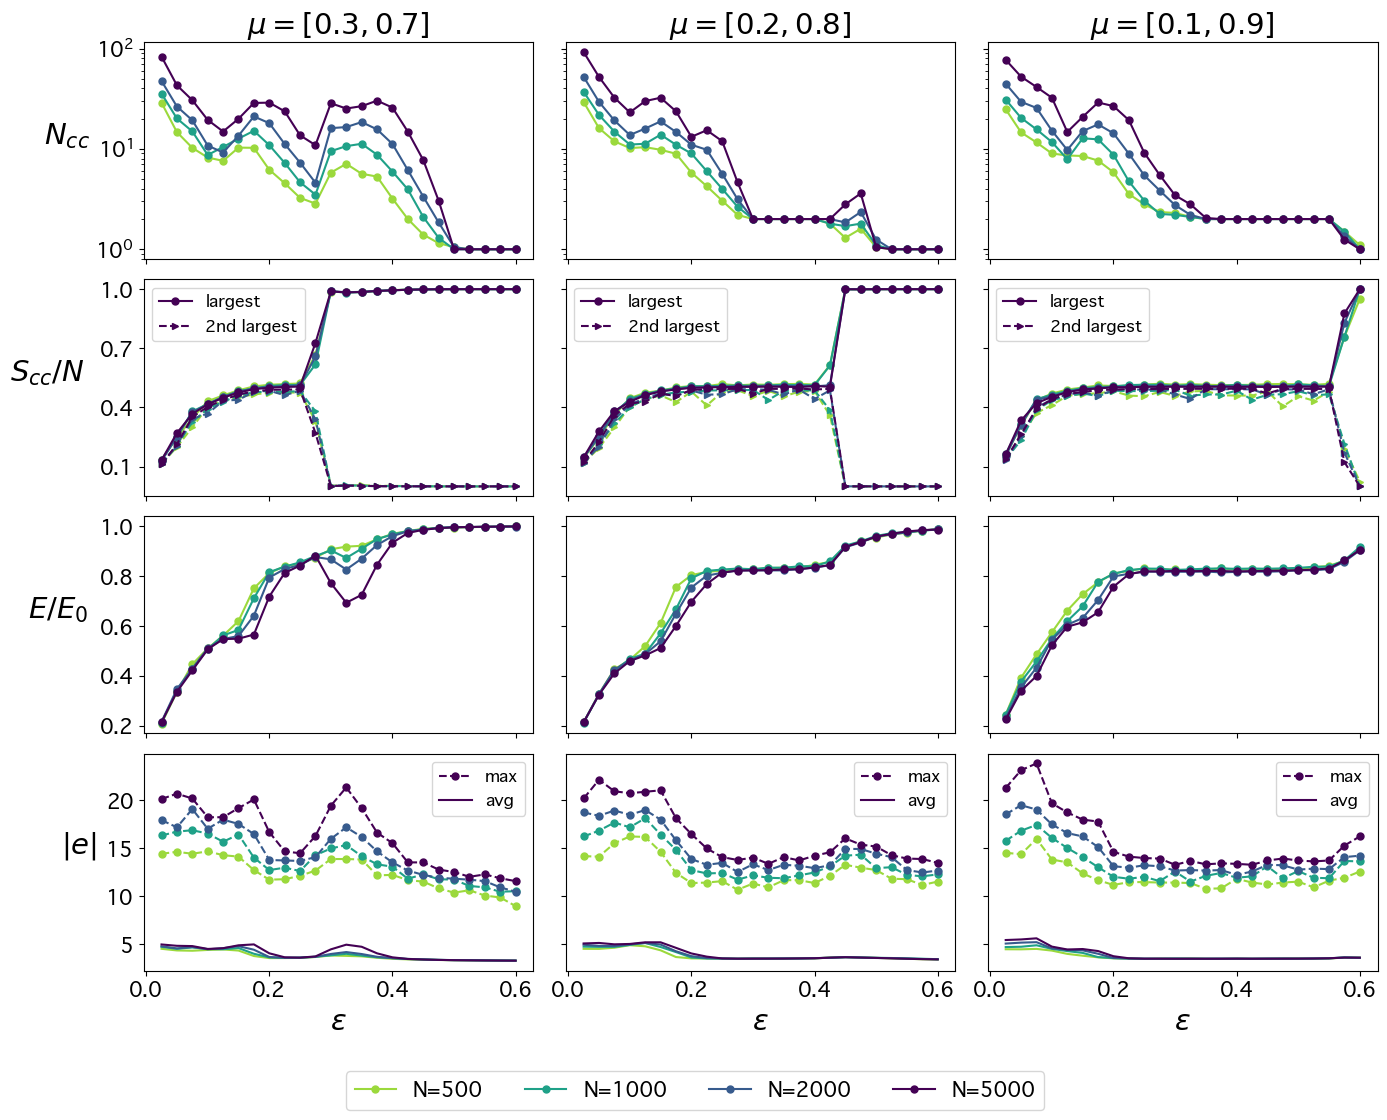

In [34]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = '246'
means_list = [[0.3,0.7], [0.2,0.8], [0.1,0.9]]

fig, axs = plt.subplots(4,3, sharex=True, sharey='row', figsize=figsize4x3)

for means in means_list:

    with open(f'../results/ER_{cond}/ER_{cond}_bimodal_{means[0]}_{means[1]}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = means_list.index(means)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[-1] else None
        la1 = lbls[1] if N==Ns[-1] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
        tk = [0.1,0.4,0.7,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        axs[1,i].legend(fontsize=lgd_size, loc=2)
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')

        la2 = lbls[2] if N==Ns[-1] else None
        la3 = lbls[3] if N==Ns[-1] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        axs[3,i].legend(fontsize=lgd_size)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)

    axs[0,i].set_title(fr'$\mu=[{means[0]},{means[1]}]$', fontsize=ttl_size4x3)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size4x3, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size4x3, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size4x3, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size4x3, labelpad=20)

for j in range(3):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size4x3)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_bimodal_M{M}.jpg', dpi=dpi)
plt.show()

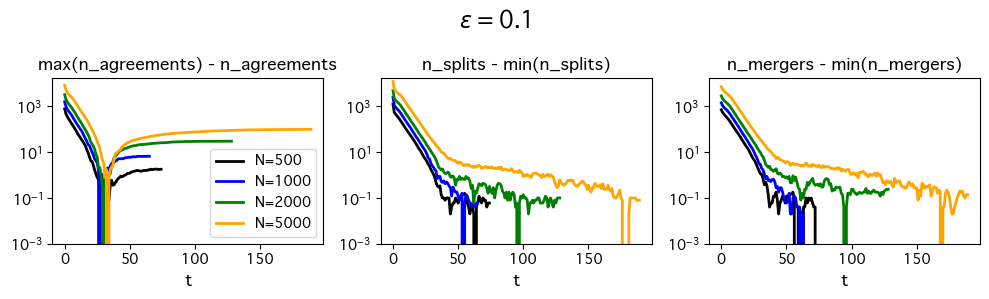

In [38]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal.pkl', 'rb') as f:
    results = pickle.load(f)

lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    n_runs = results[N]['n_runs']
    k_avg = results[N]['k_avg']
    
    n_ag = [max(n_agree) - i for i in n_agree]
    n_sp = [i - min(n_split) for i in n_split]
    n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_ag, color=clr, lw=lw, label=f'N={N}')
    ax[1].plot(n_sp, color=clr, lw=lw, label=f'N={N}')
    ax[2].plot(n_me, color=clr, lw=lw, label=f'N={N}')
    ax[0].set_title('max(n_agreements) - n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits - min(n_splits)', fontsize=ttl_size)
    ax[2].set_title('n_mergers - min(n_mergers)', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.001, 17000)
        ax[i].set_yscale('log')

plt.suptitle(rf'$\epsilon =${epsilon}', fontsize=16)

plt.tight_layout()
plt.show()

# Single run to check what happens

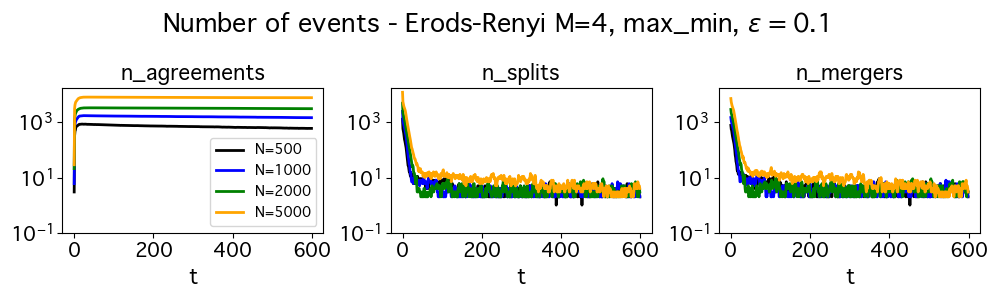

In [42]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    k_avg = results[N]['k_avg']
    
    #n_ag = [max(n_agree) - i for i in n_agree]
    #n_sp = [i - min(n_split) for i in n_split]
    #n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_agree, color=clr, lw=lw, label=f'N={N}')
    ax[1].plot(n_split, color=clr, lw=lw, label=f'N={N}')
    ax[2].plot(n_merge, color=clr, lw=lw, label=f'N={N}')
    ax[0].set_title('n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits', fontsize=ttl_size)
    ax[2].set_title('n_mergers', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].tick_params(labelsize=tick_size)
        ax[i].set_yscale('log')
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.1, 17000)
            
plt.suptitle(rf'Number of events - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=18)

plt.tight_layout()
plt.show()

N=500
Final number of different opinions:  7
Final clusters of opinions:  {0.6667: 141, 0.3771: 123, 0.9064: 102, 0.1495: 124, 0.275: 1, 0.8052: 1, 0.0288: 8} 

N=1000
Final number of different opinions:  7
Final clusters of opinions:  {0.6075: 341, 0.3064: 238, 0.1058: 180, 0.9989: 1, 0.8794: 237, 0.4545: 2, 0.9898: 1} 

N=2000
Final number of different opinions:  7
Final clusters of opinions:  {0.109: 375, 0.5131: 470, 0.9054: 376, 0.3027: 346, 0.7136: 431, 0.0048: 1, 0.0008: 1} 

N=5000
Final number of different opinions:  9
Final clusters of opinions:  {0.4993: 1243, 0.2905: 1047, 0.7114: 861, 0.0977: 855, 0.8917: 987, 0.9957: 3, 0.9988: 2, 0.9943: 1, 0.3917: 1} 



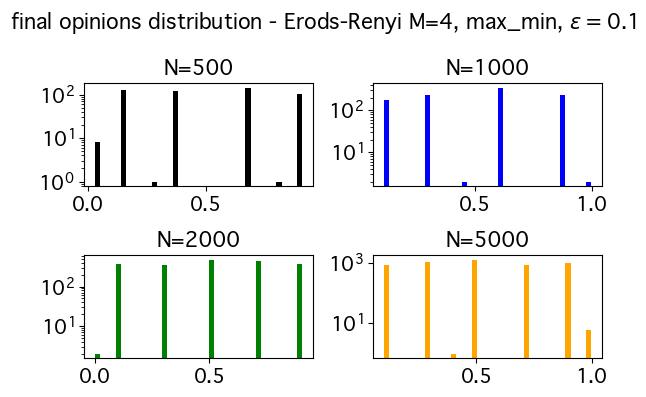

In [44]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

fig, ax = plt.subplots(2,2, figsize=(6,4))

for i in range(len(Ns)):
    N, clr = Ns[i], colors[i]
    ops_dist = results[N]['final_opinions']
    nhe = results[N]['nhe']
    k_avg = results[N]['k_avg']

    j, k = int(i/2), i%2
    ax[j,k].hist(ops_dist, bins=40, color=clr)
    ax[j,k].set_title(f'N={N}', fontsize=ttl_size)

    for i in range(4):
        ax[j,k].tick_params(labelsize=tick_size)
        ax[j,k].set_yscale('log')

    ops_dist = [np.round(i,4) for i in ops_dist]
    unique_ops = list(set(ops_dist))
    clst_op = {i :ops_dist.count(i) for i in unique_ops}
    print(f'N={N}')
    print('Final number of different opinions: ', len(unique_ops) )
    print(f'Final clusters of opinions: ', clst_op, '\n' )

plt.suptitle(rf'final opinions distribution - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=ttl_size)

plt.tight_layout()
plt.show()